# SBERT 

In [28]:
# SBERT k-NN 
import os 
import torch
from sentence_transformers import SentenceTransformer
from transformers import BertTokenizer, BertModel
from scipy.spatial.distance import cosine
import json
import re
import psycopg2
import psycopg2.extras
import numpy as np
from collections import Counter
import wordninja
import joblib
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import umap
from tqdm import tqdm
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder
import matplotlib.colors as mcolors
import distinctipy
import math
import pandas as pd
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(device)

2.5.1+cu121
cuda


In [2]:
dataset_path = Path(r'C:\Users\danie\Desktop\_\Daniela_Curmi\University\Final_Year_Project\Code_Implementation\Website')

In [3]:
# Database connection
def get_db_connection():
    conn = psycopg2.connect(
        host="localhost",
        database="ART_RECSYS_DB_LOCAL",
        user="postgres",
        password="Catmelon304!"
    )
    return conn

print(get_db_connection())

<connection object at 0x000002540C526AC0; dsn: 'user=postgres password=xxx dbname=ART_RECSYS_DB_LOCAL host=localhost', closed: 0>


## Preprocessing 

### Validation and Cleaning

Validation has already been performed in the  TF-IDF VSM notebook, hence it's possible to move directly to the NULL handling section of this pipeline.

### Handle NULLs/missing values and Text Normalisation

As discussed earlier, the following fields contain missing/null values (see histogram plot of missing values per field) and for the recommendation architecture I will be using a larger set of text field since SBERT is a transformer-based architecture, which means that model adopts the mechanism of attention, weighing the influence of different parts of the input data. 

Fields that contain missing values; 

**Painting Details** title, year_created, genre, media, description_tags

**Artist Details** nationality, feilds, art_movements, bio

Using explicit NULL tokens e.g. [GENRE] unknown genre, will allow the model to learn the lack of certain fields within a painting representation.

*N.B: The only fields that are not handled for missing values are artist and art_style because they have no missing/null values.* 

- handle missing values
- denote fields
- clean noisy data
- deduplicate tokens
- normalise structured metadata
- convert numbers to semantic representation

Raw text can't be used to extract embeddings, since the data is heterogeneous and raw concatenation has no field boundaries, and is partially structured containing missing data. 

#### Free Text 
**Title, Bio**

In [30]:
# Title preprocessing i.e. NULL/missing handling and text normalisation 
ROMAN_NUMERAL_PATTERN = re.compile(r'\b(i{1,3}|iv|v|vi{0,3}|ix|x)\b', re.IGNORECASE)

def normalise_roman_numerals(text: str) -> str:
    return ROMAN_NUMERAL_PATTERN.sub(lambda m: m.group(0).upper(), text)

def process_title(title: str) -> str:
    # Handle NULL/missing values 
    if title is None or title.strip() == "":
        return "unknown title"

    # Normalise whitespace
    title = title.strip() 
    title = re.sub(r'\s+', ' ', title)

    # Fix broken apostrophes e.g. "Martin S" to "Martin's" and normalise roman numerals
    title = re.sub(r"\b([A-Za-z]+)\s+S\b", r"\1's", title)
    title = normalise_roman_numerals(title)

    # Remove trailing index numbers only when safe
    if re.search(r'(untitled|drawing|study|composition|abstraction)', title, re.IGNORECASE):
        title = re.sub(r'\s*\(?\d+\)?$', '', title)

    title = re.sub(r'\s+', ' ', title).strip()

    return title

# Used to avoid cutting mid-word
def safe_cut(text, length):
    cut = text[:length]
    return cut[:cut.rfind(" ")] if " " in cut else cut

# Bio preprocessing, including cutoff since bio fields contain the most 
# characters and heavily bias the embedding space if left untrimmed
def process_bio(bio: str, max_chars=2000) -> str:
    if bio is None or bio.strip() == "":
        return "no biography available"
    
    # Normalise whitespace, including newlines and tabs
    bio = bio.strip()
    bio = re.sub(r'\s+', ' ', bio)

    # Truncate so that bio is token-safe for SBERT 
    if len(bio) > max_chars:
        head_len = int(max_chars * 0.6)
        tail_len = max_chars - head_len

        head = safe_cut(bio, head_len)
        tail = safe_cut(bio[::-1], tail_len)[::-1]

        bio = f"{head} ... {tail}"

    return bio


#### Categorical 
**Artist, Genre, Art Style, Nationality**


In [31]:
# This method can be used for all categorical fields, to handle NULL/missing values, convert all fields to lowercase apart 
# from artist and remove excess whitespace 
def process_categorical_field(field_value: str, field_name: str = None) -> str:
    # Handle NULL/missing values 
    if field_value is None or field_value.strip() == "":
        return f"unknown {field_name}"

    field_value = field_value.strip()

    # Normalise whitespace and convert all categoricals to lowercase except artist since it harms entity recognition
    field_value = re.sub(r'\s+', ' ', field_value)
    if field_name != "artist":
        field_value = field_value.lower()

    return field_value

#### Multi-Value Fields
**Description Tags, Media, Art Movements, Fields**


In [32]:
# This method can be used for all multi-value fields, it handles nulls/missing values, 
# converts all comma seperated items to lower case, and applies the respective preprocessing for description_tags, 
# joining all value segments using |
def process_multi_value_field(feild_value: str, field_name: str = None) -> str:
    # Handle NULL/missing values
    if feild_value is None or feild_value.strip() == "":
        return f"unknown {field_name}" 

    # Split on comma 
    items = feild_value.split(",")
    cleaned = []
    for item in items:
        item = item.strip().lower()
        if item == "":
            continue
        
        # Replace hyphens with space when in-between words only and normalise internal whitespace
        if field_name == "description tags":
            item = re.sub(r'(?<=\w)-(?=\w)', ' ', item)

            # Apply segmentation only if; no spaces already, long enough, purely alphabetic
            if " " not in item and len(item) > 10 and item.isalpha():
                split_words = wordninja.split(item)

                # Safety checks to avoid bad splits (e.g. single char fragments)
                if (len(split_words) > 1 and all(len(w) > 2 for w in split_words) and len(" ".join(split_words)) >= len(item) * 0.8):
                    item = " ".join(split_words) 

        item = re.sub(r'\s+', ' ', item)
        cleaned.append(item)

    if not cleaned:
        return f"unknown {field_name}" 

    # Deduplicate while preserving order
    unique_items = list(dict.fromkeys(cleaned))

    return " | ".join(unique_items)

#### Numerical Features
**Year Created**

In [33]:
# Instead of using years, encode them as semantic 
def process_year(year_created):
    # NULL/missing 
    if year_created is None or str(year_created).strip() == "":
        return "unknown period"

    try:
        year = int(year_created)
    except (ValueError, TypeError):
        return "unknown period"

    # Period mapping 
    if year < 1400:
        return "medieval period 14th century"
    elif year < 1600:
        return "renaissance period 16th century"
    elif year < 1700:
        return "baroque period 17th century"
    elif year < 1800:
        return "rococo enlightenment period 18th century"
    elif year <= 1850:
        return "early modern period 18th century"
    elif year <= 1900:
        return "late 19th century impressionism era"
    elif year <= 1945:
        return "early 20th century modernism"
    elif year <= 1970:
        return "mid 20th century post war modern"
    elif year <= 2000:
        return "late 20th century contemporary"
    else:
        return "contemporary period 20th century" 

In [34]:
def format_text_fields(title, year_created, genre, art_style, media, description_tags, artist, nationality, fields, art_movements, bio):
    title_processed = process_title(title)
    year_processed = process_year(year_created)
    genre_processed = process_categorical_field(genre, "genre")
    art_style_processed = process_categorical_field(art_style, "art style")
    media_processed = process_multi_value_field(media, "media")
    description_tags_processed = process_multi_value_field(description_tags, "description tags")
    artist_processed = process_categorical_field(artist, "artist")
    nationality_processed = process_categorical_field(nationality, "nationality")
    fields_processed = process_multi_value_field(fields, "fields")
    art_movements_processed = process_multi_value_field(art_movements, "art movements")
    bio_processed = process_bio(bio)

    # Structured reperesntation 
    structured = {
        "title": title_processed,
        "year_period": year_processed,
        "genre": genre_processed,
        "art_style": art_style_processed,
        "media": media_processed.split(" | "),
        "description_tags": description_tags_processed.split(" | "),
        "artist": artist_processed,
        "nationality": nationality_processed,
        "fields": fields_processed.split(" | "),
        "art_movements": art_movements_processed.split(" | "),
        "bio": bio_processed
    }

    return structured

def build_processed_texts():
    conn = get_db_connection()
    cur = conn.cursor()

    query = """
    SELECT painting_id, title, year_created, genre, art_style, media, 
        description_tags, artist, nationality, fields, art_movements, bio
    FROM paintings_and_artists_metadata_bert
    ORDER BY painting_id
    """
    cur.execute(query)
    rows = cur.fetchall()

    processed_data = []
    painting_ids = []
    for row in rows:
        (painting_id, title, year_created, genre, art_style, media, description_tags, 
         artist, nationality, fields, art_movements, bio) = row
        structured = format_text_fields(title, year_created, genre, art_style, media, description_tags, 
                                              artist, nationality, fields, art_movements, bio)
        processed_data.append((json.dumps(structured), painting_id))
        painting_ids.append(painting_id)

    conn.commit()
    cur.close()
    conn.close()

    return processed_data, painting_ids

In [ ]:
processed_data, painting_ids = build_processed_texts() 

# Backup preprocessed fields
joblib.dump(processed_data, "processed_data.pkl")

['processed_data.pkl']

In [40]:
processed_data = joblib.load("processed_data.pkl")

In [ ]:
def store_processed_data(processed_data):
    conn = get_db_connection()
    cur = conn.cursor() 
    
    for item in processed_data:
        structured_json, painting_id = item

        cur.execute("""
            UPDATE paintings_and_artists_metadata_bert
            SET processed_fields = %s
            WHERE painting_id = %s
        """, (
            structured_json,
            painting_id
        ))

    conn.commit()
    cur.close()
    conn.close()

store_processed_data(processed_data)

### Extract Embeddings using SBERT

In [ ]:
# Load SBERT model to be used for per-field embedding extraction 
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2') # all-roberta-large-v1, paraphrase-multilingual-mpnet-base-v2

def prepare_field_text(value):
    if isinstance(value, list):
        return " | ".join(value) if value else ""
    text = str(value).strip()
    return text

In [ ]:
# Extract embeddings per field for late fusion using weights 
embeddings = []
for item_json, painting_id in processed_data:
    item = json.loads(item_json)  

    item_embeddings = {}

    for field, value in item.items():
        text = prepare_field_text(value)

        if text == "":
            continue

        item_embeddings[field] = model.encode(text, normalize_embeddings=True)

    embeddings.append(item_embeddings)

# Backup embedding storage apart from DB
joblib.dump(embeddings, "SBERT_embeddings_per_field.pkl")

['SBERT_embeddings_per_field.pkl']

In [52]:
embeddings = joblib.load("SBERT_embeddings_per_field_multilingual.pkl")

In [ ]:
def to_list(array):
    if array is None:
        return None
    return array.tolist() 

def store_embeddings(embeddings, painting_ids, batch_size=500):
    conn = get_db_connection()
    cur = conn.cursor()

    batch = []

    for idx, item_embeddings in enumerate(embeddings):
        pid = painting_ids[idx]

        batch.append((
            to_list(item_embeddings.get("title")),
            to_list(item_embeddings.get("year_period")),
            to_list(item_embeddings.get("genre")),
            to_list(item_embeddings.get("art_style")),
            to_list(item_embeddings.get("description_tags")),
            to_list(item_embeddings.get("media")),
            to_list(item_embeddings.get("artist")),
            to_list(item_embeddings.get("nationality")),
            to_list(item_embeddings.get("fields")),
            to_list(item_embeddings.get("art_movements")),
            to_list(item_embeddings.get("bio")),
            pid
        ))

        if len(batch) >= batch_size:
            cur.executemany("""
                UPDATE paintings_and_artists_metadata_bert
                SET 
                    title_embedding = %s,
                    year_embedding = %s,
                    genre_embedding = %s,
                    art_style_embedding = %s,
                    description_tags_embedding = %s,
                    media_embedding = %s,
                    artist_embedding = %s,
                    nationality_embedding = %s,
                    fields_embedding = %s,
                    art_movements_embedding = %s,
                    bio_embedding = %s
                WHERE painting_id = %s
            """, batch)

            conn.commit()
            batch.clear()

    if batch:
        cur.executemany(..., batch)
        conn.commit()

    cur.close()
    conn.close()

In [ ]:
store_embeddings(embeddings, painting_ids)

### Build per-field Embedding Matrices

In [53]:
FIELDS = [
    "title", 
    "year_period", 
    "genre", 
    "art_style",
    "description_tags", 
    "media", 
    "artist",
    "nationality", 
    "fields", 
    "art_movements", 
    "bio"
]

def build_embedding_matrices(embeddings):
    embedding_matrices = {}
    for field in FIELDS:
        vectors = []

        all_vecs = [item[field] for item in embeddings if field in item]
        mean_vec = np.mean(all_vecs, axis=0)

        for item in embeddings:
            vec = item.get(field)
            
            if vec is None:
                vec = item.get(field, mean_vec) # fallback, since zero will create 0 similarity score when using cosine similarity
            vectors.append(vec)

        embedding_matrices[field] = np.vstack(vectors)  # shape: (N, 768)
    return embedding_matrices

embedding_matrices = build_embedding_matrices(embeddings)

In [28]:
print(embedding_matrices)

{'title': array([[-0.00107514, -0.07139069,  0.00292242, ..., -0.00744759,
         0.03193166, -0.03442939],
       [-0.01463944,  0.00509586,  0.01639824, ..., -0.00085918,
         0.01304694, -0.02174195],
       [-0.01432553, -0.02987965, -0.0051297 , ..., -0.02024694,
         0.01124819, -0.0239872 ],
       ...,
       [-0.02439257,  0.00367723, -0.01283118, ...,  0.0276729 ,
         0.04638157, -0.0211883 ],
       [ 0.02031488, -0.04543445, -0.02877787, ...,  0.01795572,
        -0.01322378,  0.02816239],
       [-0.01364143, -0.03255045, -0.02543386, ..., -0.00720913,
        -0.03787489,  0.0216038 ]], dtype=float32), 'year_period': array([[-0.03678198, -0.02405479,  0.00835123, ...,  0.05739656,
        -0.02613153,  0.02129002],
       [-0.03678198, -0.02405479,  0.00835123, ...,  0.05739656,
        -0.02613153,  0.02129002],
       [-0.03678198, -0.02405479,  0.00835123, ...,  0.05739656,
        -0.02613153,  0.02129002],
       ...,
       [ 0.00486143, -0.02282704, 

In [30]:
for field, mat in embedding_matrices.items():
    print(field, mat.shape)

title (81444, 768)
year_period (81444, 768)
genre (81444, 768)
art_style (81444, 768)
description_tags (81444, 768)
media (81444, 768)
artist (81444, 768)
nationality (81444, 768)
fields (81444, 768)
art_movements (81444, 768)
bio (81444, 768)


In [37]:
embedding_matrices = joblib.load("SBERT_embedding_matrices.pkl")

#### Test Query Embedding of Painting User Interacted with

In [38]:
# Raw Test Query 
query = {
    "painting_id" : "55055",
    "title": "Public Garden With Fence",
    "year_created": "1888",
    "description_tags": "Gardens-And-Parks",
    "media": "ink,paper",
    "genre": "sketch and study",
    "art_style": "Post Impressionism",
    "artist": "Vincent Van Gogh",
    "art_movements": "Post-Impressionism",
    "fields": "painting",
    "nationality": "Dutch",
    "bio": "Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty. Born into an upper-middle-class family, Van Gogh drew as a child and was serious, quiet and thoughtful. As a young man he worked as an art dealer, often travelling, but became depressed after he was transferred to London. He turned to religion, and spent time as a Protestant missionary in southern Belgium. He drifted in ill health and solitude before taking up painting in 1881, having moved back home with his parents. His younger brother Theo supported him financially, and the two kept up a long correspondence by letter. His early works, mostly still lifes and depictions of peasant labourers, contain few signs of the vivid colour that distinguished his later work. In 1886, he moved to Paris, where he met members of the avant-garde, including Émile Bernard and Paul Gauguin, who were reacting against the Impressionist sensibility. As his work developed he created a new approach to still lifes and local landscapes. His paintings grew brighter in colour as he developed a style that became fully realised during his stay in Arles in the south of France in 1888. During this period he broadened his subject matter to include series of olive trees, wheat fields and sunflowers. Van Gogh suffered from psychotic episodes and delusions and though he worried about his mental stability, he often neglected his physical health, did not eat properly and drank heavily. His friendship with Gauguin ended after a confrontation with a razor, when in a rage, he severed part of his own left ear. He spent time in psychiatric hospitals, including a period at Saint-Rémy. After he discharged himself and moved to the Auberge Ravoux in Auvers-sur-Oise near Paris, he came under the care of the homoeopathic doctor Paul Gachet. His depression continued and on 27 July 1890, Van Gogh shot himself in the chest with a revolver. He died from his injuries two days later. Van Gogh was unsuccessful during his lifetime, and was considered a madman and a failure. He became famous after his suicide, and exists in the public imagination as the quintessential misunderstood genius, the artist 'where discourses on madness and creativity converge'. His reputation began to grow in the early 20th century as elements of his painting style came to be incorporated by the Fauves and German Expressionists. He attained widespread critical, commercial and popular success over the ensuing decades, and is remembered as an important but tragic painter, whose troubled personality typifies the romantic ideal of the tortured artist."
}

query_clean = format_text_fields(query["title"], query["year_created"], query["genre"], query["art_style"], query["media"],
                    query["description_tags"], query["artist"], query["art_movements"], query["fields"], query["nationality"], 
                    query["bio"])
print(query_clean)

def encode_query_sbert(query_structured, model):
    query_embeddings = {}

    for field, value in query_structured.items():
        text = prepare_field_text(value)

        if text == "":
            continue

        query_embeddings[field] = model.encode(text, normalize_embeddings=True)
    return query_embeddings

{'title': 'Public Garden With Fence', 'year_period': 'late 19th century impressionism era', 'genre': 'sketch and study', 'art_style': 'post impressionism', 'media': ['ink', 'paper'], 'description_tags': ['gardens and parks'], 'artist': 'Vincent Van Gogh', 'nationality': 'post-impressionism', 'fields': ['painting'], 'art_movements': ['dutch'], 'bio': "Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty. Born into an up

In [29]:
WEIGHTS = {
    "title": 0.1,
    "genre": 0.1,
    "art_style": 0.2,
    "description_tags": 0.1,
    "media": 0.05,
    "year_period": 0.05,
    "artist": 0.05,
    "nationality": 0.03,
    "fields": 0.03,
    "art_movements": 0.1,
    "bio": 0.03   
}

def normalise_weights(weights):
    total = sum(weights.values())
    return {k: v / total for k, v in weights.items()}

WEIGHTS = normalise_weights(WEIGHTS)

def compute_similarity_per_field_sbert(query_embeddings, embedding_matrices):
    similarities = {}

    for field, matrix in embedding_matrices.items():
        q = query_embeddings.get(field)

        if q is None:
            similarities[field] = np.zeros(matrix.shape[0])
            continue

        sim = matrix @ q   
        similarities[field] = sim

    return similarities

def weighted_late_fusion(similarities, weights):
    final_scores = np.zeros(len(next(iter(similarities.values()))))

    for field, sim in similarities.items():
        final_scores += weights.get(field, 0) * sim

    return final_scores

def get_top_k(final_scores, query_index, k=30):
    final_scores = final_scores.copy()
    final_scores[query_index] = -np.inf
    top_indices = np.argpartition(final_scores, -k)[-k:]
    top_indices = top_indices[np.argsort(final_scores[top_indices])[::-1]]
    return top_indices, final_scores[top_indices]

In [41]:
painting_id_to_index = {
    pid: idx for idx, (_, pid) in enumerate(processed_data)
}
def recommend_sbert(query_structured, model, embedding_matrices, weights, painting_id_to_index, query_id, k=10):
    query_embeddings = encode_query_sbert(query_structured, model)
    similarities = compute_similarity_per_field_sbert(query_embeddings, embedding_matrices)
    final_scores = weighted_late_fusion(similarities, weights)
    query_index = painting_id_to_index[int(query_id)]
    top_indices, scores = get_top_k(final_scores, query_index, k)
    return top_indices, scores, similarities

top_indices, scores, similarities = recommend_sbert(query_clean, model, embedding_matrices, WEIGHTS, painting_id_to_index, query["painting_id"])

def fetch_paintings(painting_ids):
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    # Preserve order 
    cur.execute("""
        SELECT 
            painting_id,
            title,
            year_created,
            artist,
            genre, 
            art_style,
            media,
            description_tags,
            nationality,
            fields, 
            art_movements,
            bio,
            image_path
        FROM paintings_and_artists_metadata_bert
        WHERE painting_id = ANY(%s)
        ORDER BY array_position(%s, painting_id);
    """, (painting_ids, painting_ids))

    rows = cur.fetchall()

    cur.close()
    conn.close()

    return rows

query_embeddings = encode_query_sbert(query_clean, model)
query_id = query["painting_id"]
query_index = painting_id_to_index[int(query_id)]
print(np.allclose(embedding_matrices["title"][query_index], query_embeddings["title"]))

True


1. Painting ID: 55052, Score: 0.8199
   Title: Public Garden With A Couple And A Blue Fir Tree
   Artist: Vincent Van Gogh
   Year Created: 1888
   Genre: sketch and study
   Art Style: Post Impressionism
   Media: ink,paper
   Description Tags: Gardens-And-Parks,Text,Handwriting,Font
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and pove

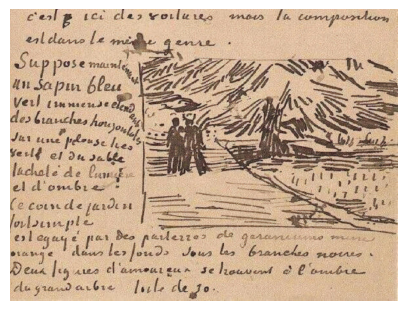

2. Painting ID: 55050, Score: 0.8141
   Title: Prisoners Exercising Prisoners Round
   Artist: Vincent Van Gogh
   Year Created: 1890
   Genre: None
   Art Style: Post Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.
 Born into an upper-middle-class family, Van Gogh drew as 

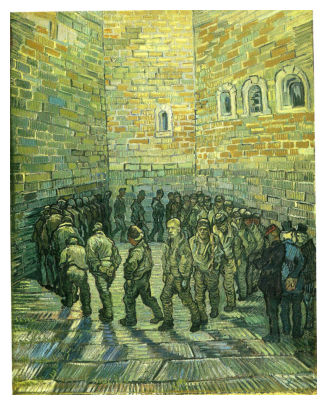

3. Painting ID: 55055, Score: 0.8113
   Title: Public Garden With Fence
   Artist: Vincent Van Gogh
   Year Created: 1888
   Genre: sketch and study
   Art Style: Post Impressionism
   Media: ink,paper
   Description Tags: Gardens-And-Parks
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.
 Born into an upper-middle-class family,

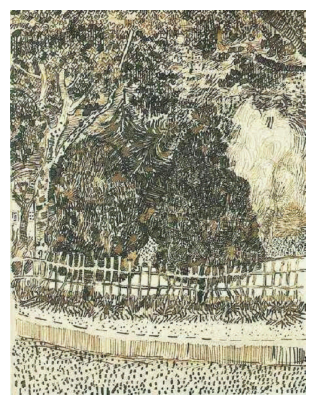

4. Painting ID: 55051, Score: 0.8048
   Title: Public Garden With A Corner Of The Yellow House
   Artist: Vincent Van Gogh
   Year Created: 1888
   Genre: sketch and study
   Art Style: Post Impressionism
   Media: ink,paper
   Description Tags: Gardens-And-Parks,Arles,Tree,Botany
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.

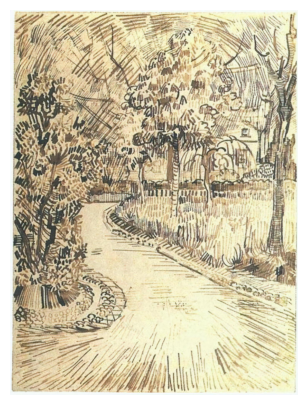

5. Painting ID: 55301, Score: 0.7992
   Title: The Garden Of St Paul S Hospital At St Remy
   Artist: Vincent Van Gogh
   Year Created: 1889
   Genre: None
   Art Style: Post Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.
 Born into an upper-middle-class family, Van Gogh d

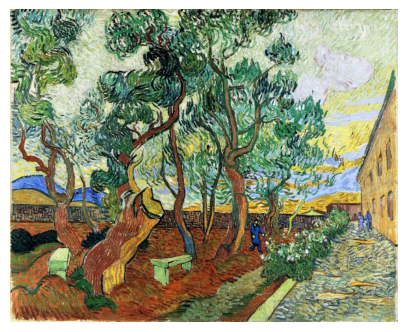

6. Painting ID: 54893, Score: 0.7922
   Title: Meadow With Flowers
   Artist: Vincent Van Gogh
   Year Created: 1888
   Genre: landscape
   Art Style: Post Impressionism
   Media: pencil,ink,paper
   Description Tags: Fields-And-Plains,Barley,Field,Plant,Grassfamily,Grass,Rye,Crop
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.

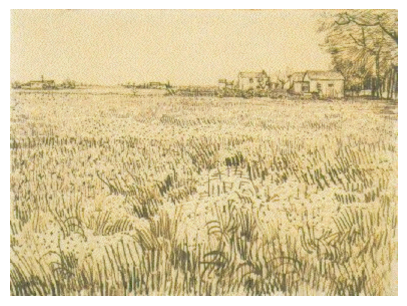

7. Painting ID: 55078, Score: 0.7875
   Title: Roses And Beetle
   Artist: Vincent Van Gogh
   Year Created: 1890
   Genre: flower painting
   Art Style: Post Impressionism
   Media: oil,canvas
   Description Tags: Flowers-And-Plants,Insects,Beetles,Flower,Plant,Gardenroses
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.
 Born 

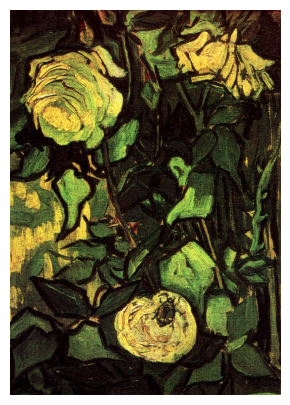

8. Painting ID: 54934, Score: 0.7849
   Title: Orchard And House With Orange Roof  1
   Artist: Vincent Van Gogh
   Year Created: 1888
   Genre: None
   Art Style: Post Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.
 Born into an upper-middle-class family, Van Gogh drew as

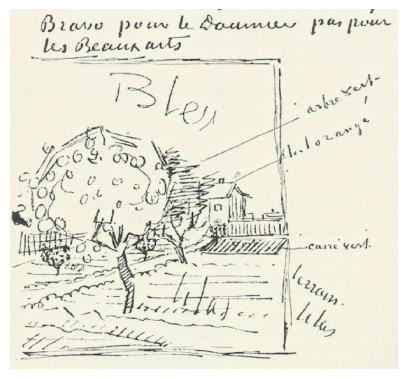

9. Painting ID: 55286, Score: 0.7726
   Title: The Church At Auvers
   Artist: Vincent Van Gogh
   Year Created: 1890
   Genre: cityscape
   Art Style: Post Impressionism
   Media: oil,canvas
   Description Tags: Auvers-Sur-Oise,House,Building,Sky
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.
 Born into an upper-middle-class 

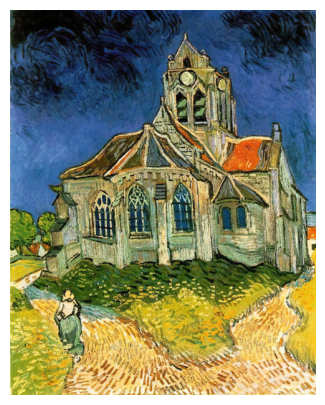

10. Painting ID: 54856, Score: 0.7712
   Title: Landscape With The Oise
   Artist: Vincent Van Gogh
   Year Created: 1890
   Genre: sketch and study
   Art Style: Post Impressionism
   Media: pencil,paper
   Description Tags: Rivers-And-Waterfalls,Sketch
   Fields: painting
   Art Movements: Post-Impressionism
   Nationality: Dutch
   Bio: Vincent Willem van Gogh (Dutch: [ˈvɪnsɛnt ˈʋɪləm vɑn ˈɣɔx] ( listen); 30 March 1853 – 29 July 1890) was a Dutch Post-Impressionist painter who is among the most famous and influential figures in the history of Western art. In just over a decade he created about 2,100 artworks, including around 860 oil paintings, most of them in the last two years of his life. They include landscapes, still lifes, portraits and self-portraits, and are characterised by bold colours and dramatic, impulsive and expressive brushwork that contributed to the foundations of modern art. His suicide at 37 followed years of mental illness and poverty.
 Born into an upper-middle

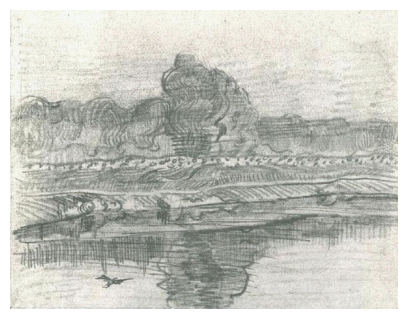

In [23]:
# Fetch the top painting metadata and image paths from the database
painting_ids = top_indices.tolist()
paintings = fetch_paintings(painting_ids)

for rank, painting in enumerate(paintings, start=1):
    print(f"{rank}. Painting ID: {painting['painting_id']}, Score: {scores[rank-1]:.4f}")
    print(f"   Title: {painting['title']}")
    print(f"   Artist: {painting['artist']}")
    print(f"   Year Created: {painting['year_created']}")
    print(f"   Genre: {painting['genre']}")
    print(f"   Art Style: {painting['art_style']}")
    print(f"   Media: {painting['media']}")
    print(f"   Description Tags: {painting['description_tags']}")
    print(f"   Fields: {painting['fields']}")
    print(f"   Art Movements: {painting['art_movements']}")
    print(f"   Nationality: {painting['nationality']}")
    print(f"   Bio: {painting['bio']}")
    print(f"   Image Path: {painting['image_path']}")

    image_path = painting.get('image_path')
    if image_path:
        image_path = (dataset_path / image_path).resolve()
        image = cv2.imread(str(image_path))
        if image is not None:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(5, 5))
            plt.imshow(image_rgb)
            plt.axis('off')
            plt.show()
        else:
            print(f"Unable to load image from path: {image_path}")
    else:
        print("No image_path available for this painting.")

#### Per-Field Contribution Analysis

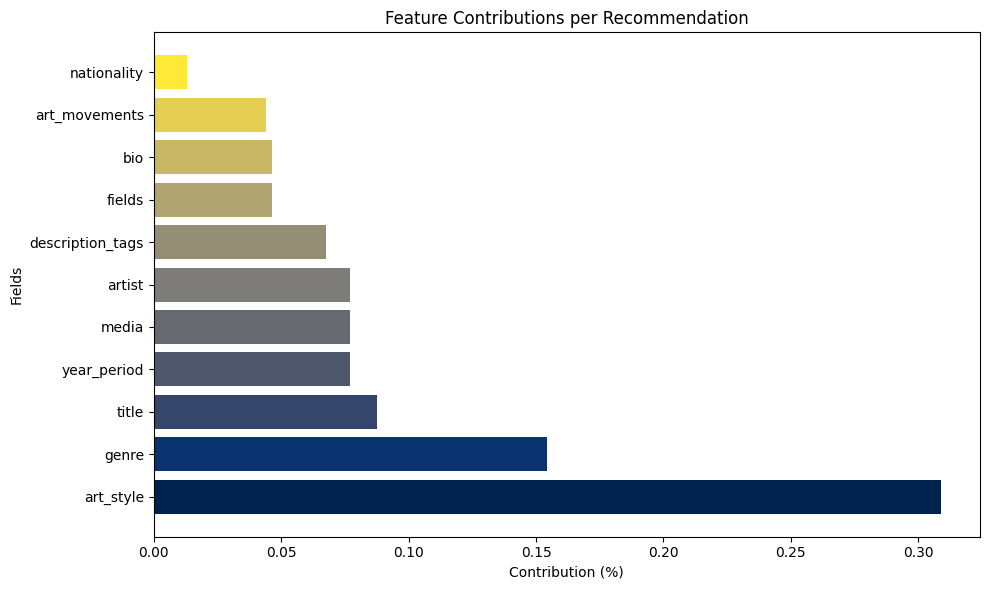

In [24]:
def compute_feature_contributions(similarities, weights, retrieved_doc_idx):
    contributions = {}
    total = 0

    for field in similarities:
        value = weights[field] * similarities[field][retrieved_doc_idx]
        contributions[field] = value
        total += value

    # Normalise to percentages
    normalised = {
        field: (value / total if total != 0 else 0)
        for field, value in contributions.items()
    }

    return contributions, normalised, total

# Compute contributions
retrieved_doc_index = top_indices[9]
contribs, norm_contribs, total = compute_feature_contributions(similarities, WEIGHTS, retrieved_doc_index)
sorted_items = sorted(norm_contribs.items(), key=lambda x: x[1], reverse=True)

labels = [k.replace('_missing', '') for k, _ in sorted_items]
values = [v for _, v in sorted_items]

cmap = plt.cm.cividis
colors = [cmap(i / max(len(values) - 1, 1)) for i in range(len(values))]

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.barh(labels, values, color=colors)

plt.title("Feature Contributions per Recommendation")
plt.xlabel("Contribution (%)")
plt.ylabel("Fields")

plt.tight_layout()
plt.show()

### Visualise Embedding Space

In [85]:
X = embedding_matrices["year_period"] 

umap_dim_red = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
emb_2d = umap_dim_red.fit_transform(X)

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


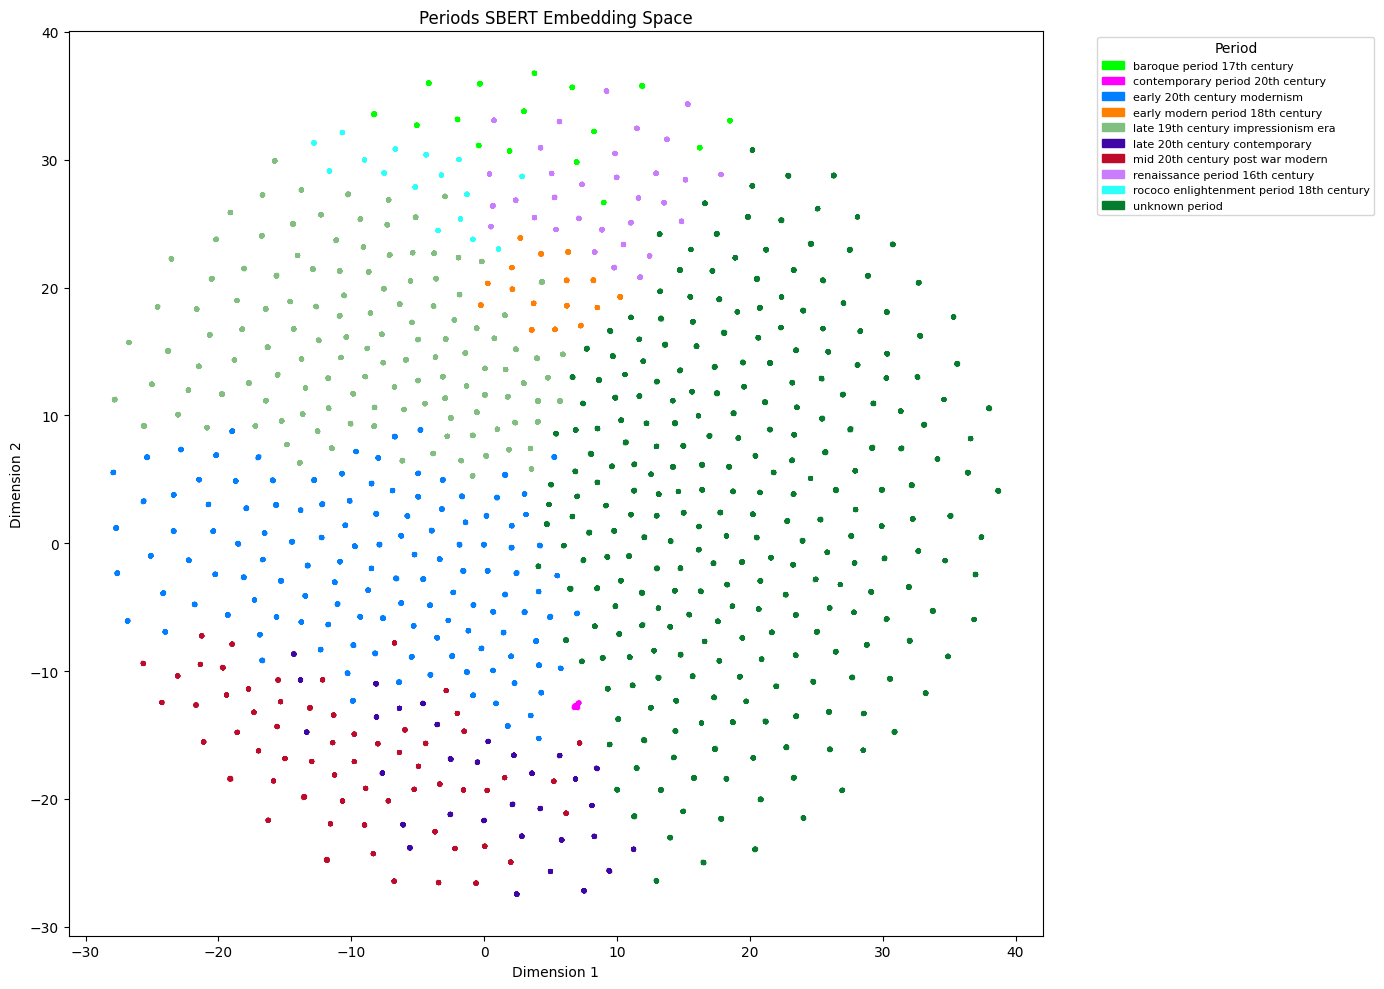

In [87]:
labels = []

for item_json, _ in processed_data:
    item = json.loads(item_json)

    labels.append(item["year_period"])

encoder = LabelEncoder()
label_ids = encoder.fit_transform(labels)

def distinct_cmap(n=35):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [
        mcolors.hsv_to_rgb((h, 0.75, 0.95))
        for h in hues
    ]

#colors = distinct_cmap(len(encoder.classes_))
colors = distinctipy.get_colors(len(encoder.classes_))

plt.figure(figsize=(14, 10))

point_colors = [colors[i] for i in label_ids]

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=point_colors,
    s=6,
    alpha=0.2
)


# legend
legend_handles = [
    mpatches.Patch(color=colors[i], label=label)
    for i, label in enumerate(encoder.classes_)
]

plt.legend(
    handles=legend_handles,
    title="Period",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8
)

plt.title("Periods SBERT Embedding Space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.show()

In [ ]:
def build_combined_embeddings(embedding_matrices, weights):
    combined = None

    for field, matrix in embedding_matrices.items():
        weighted = matrix * weights[field]

        if combined is None:
            combined = weighted
        else:
            combined += weighted

    return combined

combined_embeddings = build_combined_embeddings(
    embedding_matrices,
    WEIGHTS
)

emb_2d = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    random_state=42
).fit_transform(combined_embeddings)

In [ ]:
encoder = LabelEncoder()
label_ids = encoder.fit_transform(labels)

def distinct_cmap(n=35):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [
        mcolors.hsv_to_rgb((h, 0.75, 0.95))
        for h in hues
    ]

#colors = distinct_cmap(len(encoder.classes_))
colors = distinctipy.get_colors(len(encoder.classes_))

plt.figure(figsize=(14, 10))

point_colors = [colors[i] for i in label_ids]
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=point_colors,
    s=10,
    alpha=0.3
)

# legend
legend_handles = [
    mpatches.Patch(color=colors[i], label=label)
    for i, label in enumerate(encoder.classes_)
]

plt.legend(
    handles=legend_handles,
    title="Art Styles",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.title("Art Style SBERT Embedding Space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.show()

In [53]:
print(len(np.unique(combined_embeddings, axis=0)))

78321


# Evaluation 

**Predictive Quality Metrics**; Precision@k

**Ranking Quality Metrics**; MRR, MAP, NDCG, Hit Rate

**Behavioural Metrics**; Diversity, Novelty, Serendipity, Popularity bias 

https://www.evidentlyai.com/ranking-metrics/evaluating-recommender-systems#map

In [3]:
# Database connection
def get_db_connection():
    conn = psycopg2.connect(
        host="localhost",
        database="Evaluation_DB",
        user="postgres",
        password="Catmelon304!"
    )
    return conn

print(get_db_connection())

<connection object at 0x0000024014027CD0; dsn: 'user=postgres password=xxx dbname=Evaluation_DB host=localhost', closed: 0>


### Predictive and Ranking Quality Metrics
Such metrics reflect the “correctness” of recommendations and show how well the system finds relevant items

#### Precision@k, nDCG@k, mAP@k, MRR@k, HitRate@k

In [ ]:
# Metrics for one user and one set of recommendations + interactions
def metrics_one_one(user_id, request_id):
    conn = get_db_connection()
    cur = conn.cursor()

    # Get recommendations 
    cur.execute("""
        SELECT painting_id, rank
        FROM recommendations_sbert
        WHERE user_id = %s AND request_id = %s
        ORDER BY rank ASC
        LIMIT 20
    """, (user_id, request_id))

    recs = cur.fetchall()

    # Enforce minimum size requirement
    if len(recs) < 20:
        conn.close()
        return None  

    recommended_ids = [r[0] for r in recs]

    # Get relevant interactions for same request
    cur.execute("""
        SELECT painting_id, favourite, rating, click, viewing_time_seconds, review
        FROM interaction_summary
        WHERE user_id = %s AND request_id = %s
    """, (user_id, request_id))

    interactions = cur.fetchall()

    relevant_ids = set()
    for row in interactions:
        pid, favourite, rating, click, viewing_time_seconds, review = row

        if (
            favourite is True or
            click is True or
            (rating is not None and rating >= 4) or
            (viewing_time_seconds is not None and viewing_time_seconds>=3) or
            review is not None
        ):
            relevant_ids.add(pid)

    # Compute hits
    hits = sum(1 for pid in recommended_ids if pid in relevant_ids)
    precision = hits / 20.0
    hit_rate = 1.0 if hits > 0 else 0.0

    reciprocal_rank = 0.0

    for idx, pid in enumerate(recommended_ids):

        if pid in relevant_ids:
            reciprocal_rank = 1.0 / (idx + 1)
            break

    dcg = 0.0
    for idx, pid in enumerate(recommended_ids):

        if pid in relevant_ids:
            dcg += 1.0 / math.log2(idx + 2)

    ideal_hits = min(len(relevant_ids), 20)
    idcg = 0.0

    for i in range(ideal_hits):
        idcg += 1.0 / math.log2(i + 2)
    if idcg > 0:
        ndcg = dcg / idcg
    else:
        ndcg = 0.0

    ap_sum = 0.0
    hit_count = 0

    for idx, pid in enumerate(recommended_ids):
        if pid in relevant_ids:
            hit_count += 1
            precision_at_i = hit_count / (idx + 1)
            ap_sum += precision_at_i

    if len(relevant_ids) > 0:
        map_k = ap_sum / min(len(relevant_ids), 20)
    else:
        map_k = 0.0

    conn.close()

    return {
        "precision@20": precision,
        "ndcg@20": ndcg,
        "map@20": map_k,
        "hitrate@20": hit_rate,
        "mrr@20": reciprocal_rank,
        "relevant_items": len(relevant_ids)
    }

# Test for one user and one set of recommendations
metrics_one_one(11, "27bcc9d8-c5b0-47d8-a549-1a0230c0fef8")

{'precision@20': 0.15,
 'ndcg@20': 0.3809748461933143,
 'map@20': 0.16278166278166278,
 'hitrate@20': 1.0,
 'mrr@20': 0.09090909090909091,
 'relevant_items': 3}

In [26]:
# Metrics for one user, over all sets of recommendation + interactions
def metrics_one_all(user_id):
    conn = get_db_connection()
    cur = conn.cursor()

    # Get valid request_ids (must have >= 20 recs)
    cur.execute("""
        SELECT request_id
        FROM recommendations_sbert
        WHERE user_id = %s and score > 0
        GROUP BY request_id
        HAVING COUNT(*) >= 20
    """, (user_id,))

    request_ids = [r[0] for r in cur.fetchall()]

    if len(request_ids) == 0:
        conn.close()
        return None

    precisions = []
    ndcgs = []
    maps = []
    hitrates = []
    mrrs = []

    for request_id in request_ids:

        # Top 20 recommendations for this request
        cur.execute("""
            SELECT painting_id
            FROM recommendations_sbert
            WHERE user_id = %s AND request_id = %s
            ORDER BY rank ASC
            LIMIT 20
        """, (user_id, request_id))

        recs = cur.fetchall()
        recommended_ids = [r[0] for r in recs]

        if len(recommended_ids) < 20:
            continue

        # Get relevant interactions for same request
        cur.execute("""
            SELECT painting_id, favourite, rating, click, viewing_time_seconds, review
            FROM interaction_summary
            WHERE user_id = %s AND request_id = %s
        """, (user_id, request_id))

        interactions = cur.fetchall()

        relevant_ids = set()
        for row in interactions:
            favourite, rating, click, viewing_time_seconds, review = row[1], row[2], row[3], row[4], row[5]

            if (
                favourite is True or
                click is True or
                (rating is not None and rating >= 4) or
                (viewing_time_seconds is not None and viewing_time_seconds>=3) or
                review is not None
            ):
                relevant_ids.add(row[0])

        # Compute precision for this request
        hits = sum(1 for pid in recommended_ids if pid in relevant_ids)
        precision = hits / 20.0

        hitrate = 1.0 if hits > 0 else 0.0

        reciprocal_rank = 0.0
        for idx, pid in enumerate(recommended_ids):

            if pid in relevant_ids:
                reciprocal_rank = 1.0 / (idx + 1)
                break

        dcg = 0.0
        for idx, pid in enumerate(recommended_ids):

            if pid in relevant_ids:
                dcg += 1.0 / math.log2(idx + 2)

        ideal_hits = min(len(relevant_ids), 20)
        idcg = 0.0
        for i in range(ideal_hits):
            idcg += 1.0 / math.log2(i + 2)
        if idcg > 0:
            ndcg = dcg / idcg
        else:
            ndcg = 0.0

        ap_sum = 0.0
        hit_count = 0
        for idx, pid in enumerate(recommended_ids):
            if pid in relevant_ids:
                hit_count += 1
                precision_at_i = hit_count / (idx + 1)
                ap_sum += precision_at_i
        if len(relevant_ids) > 0:
            map_k = ap_sum / min(len(relevant_ids), 20)
        else:
            map_k = 0.0

        precisions.append(precision)
        ndcgs.append(ndcg)
        maps.append(map_k)
        hitrates.append(hitrate)
        mrrs.append(reciprocal_rank)

    conn.close()

    if len(precisions) == 0:
        return None

    return {
        "precision@20": sum(precisions) / len(precisions),
        "ndcg@20": sum(ndcgs) / len(ndcgs),
        "map@20": sum(maps) / len(maps),
        "hitrate@20": sum(hitrates) / len(hitrates),
        "mrr@20": sum(mrrs) / len(mrrs),
        "number_of_recommendation_sets": len(precisions)
    }

metrics_one_all(11)

{'precision@20': 0.041666666666666664,
 'ndcg@20': 0.2042074531494154,
 'map@20': 0.10802312086109817,
 'hitrate@20': 0.5,
 'mrr@20': 0.12750758839639126,
 'number_of_recommendation_sets': 90}

In [27]:
# Metrics for all users over all sets of recommendations
def metrics_all_users():

    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT DISTINCT user_id
        FROM recommendations_sbert
        ORDER BY user_id
    """)

    users = [row[0] for row in cur.fetchall()]
    conn.close()

    per_user_metrics = {}

    system_precisions = []
    system_ndcgs = []
    system_maps = []
    system_hitrates = []
    system_mrrs = []

    for user_id in users:
        metrics = metrics_one_all(user_id)

        if metrics is None:
            continue

        # Store per-user metrics
        per_user_metrics[user_id] = metrics

        # Accumulate system metrics
        system_precisions.append(metrics["precision@20"])
        system_ndcgs.append(metrics["ndcg@20"])
        system_maps.append(metrics["map@20"])
        system_hitrates.append(metrics["hitrate@20"])
        system_mrrs.append(metrics["mrr@20"])

    if len(system_precisions) == 0:
        return None

    results = {
        "system_metrics": {
            "precision@20":
                sum(system_precisions) / len(system_precisions),
            "ndcg@20":
                sum(system_ndcgs) / len(system_ndcgs),
            "map@20":
                sum(system_maps) / len(system_maps),
            "hitrate@20":
                sum(system_hitrates) / len(system_hitrates),
            "mrr@20":
                sum(system_mrrs) / len(system_mrrs)
        },
        "per_user_metrics": per_user_metrics
    }

    return results

results = metrics_all_users()

print("Metrics for all users and all recommendation batches per user: ", results["system_metrics"])
print("Metrics for each users and all recommendation batches per user:", results["per_user_metrics"])

Metrics for all users and all recommendation batches per user:  {'precision@20': 0.01769874519684044, 'ndcg@20': 0.09314431573260676, 'map@20': 0.0538323358848845, 'hitrate@20': 0.20926547850634264, 'mrr@20': 0.06440615126123633}
Metrics for each users and all recommendation batches per user: {11: {'precision@20': 0.041666666666666664, 'ndcg@20': 0.2042074531494154, 'map@20': 0.10802312086109817, 'hitrate@20': 0.5, 'mrr@20': 0.12750758839639126, 'number_of_recommendation_sets': 90}, 12: {'precision@20': 0.022727272727272728, 'ndcg@20': 0.12694222094330135, 'map@20': 0.08712121212121211, 'hitrate@20': 0.22727272727272727, 'mrr@20': 0.09848484848484848, 'number_of_recommendation_sets': 22}, 13: {'precision@20': 0.0035714285714285718, 'ndcg@20': 0.030762611290956646, 'map@20': 0.017857142857142856, 'hitrate@20': 0.07142857142857142, 'mrr@20': 0.017857142857142856, 'number_of_recommendation_sets': 14}, 16: {'precision@20': 0.058695652173913045, 'ndcg@20': 0.26814172231901867, 'map@20': 0.1

## Behavioural Metrics

#### Diversity 

Measures how similar the recommended items are to each other, thus Intra List Similarity (ILS), where low similarity indicates high diversity and high similarity indicates redundant recommendations due to high similarity.

For a recommendation list:

$$
R = \{ i_1, \dots, i_K \}
$$

the Intra-List Similarity (ILS) is defined as:

$$
ILS = \frac{2}{K(K - 1)} \sum_{a < b} \mathrm{sim}(i_a, i_b)
$$

where $\mathrm{sim}(i_a, i_b)$ is a similarity function between items $i_a$ and $i_b$.

Diversity is then defined as:

$$
Diversity = 1 - ILS
$$

In [ ]:
def build_weighted_sbert_item_vectors(embedding_matrices, weights):
    """
    Converts multiple SBERT field embedding matrices into one item vector matrix.

    embedding_matrices:
        dict[field_name] = np.array of shape (num_items, embedding_dim)

    weights:
        dict[field_name] = float
    """

    weighted_matrices = []

    for field, matrix in embedding_matrices.items():
        weight = weights.get(field, 0.0)
        weighted_matrix = matrix * weight
        weighted_matrices.append(weighted_matrix)

    item_vectors = np.hstack(weighted_matrices)
    item_vectors = normalize(item_vectors, norm="l2")

    return item_vectors

sbert_item_vectors = build_weighted_sbert_item_vectors(embedding_matrices, WEIGHTS)

In [43]:
def compute_diversity(top_indices, item_vectors):
    vectors = item_vectors[top_indices]
    sim_matrix = cosine_similarity(vectors)
    k = len(top_indices)
    pairwise_sims = sim_matrix[np.triu_indices(k, k=1)]
    ils = np.mean(pairwise_sims) if len(pairwise_sims) > 0 else 0.0
    diversity = 1.0 - ils
    return diversity

In [47]:
def diversity_one_one(user_id, request_id, item_vectors, painting_id_to_index, k=20):
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT painting_id
        FROM recommendations_sbert
        WHERE user_id = %s
          AND request_id = %s
          AND score > 0
        ORDER BY rank ASC
        LIMIT %s
    """, (user_id, request_id, k))

    recs = cur.fetchall()

    cur.close()
    conn.close()

    if len(recs) < k:
        return None

    painting_ids = [row[0] for row in recs]

    top_indices = [
        painting_id_to_index[int(pid)]
        for pid in painting_ids
        if int(pid) in painting_id_to_index
    ]

    if len(top_indices) < k:
        return None

    diversity = compute_diversity(top_indices, item_vectors)

    return diversity

print(diversity_one_one(11, "27bcc9d8-c5b0-47d8-a549-1a0230c0fef8", sbert_item_vectors, painting_id_to_index, k=20))

0.6528856754302979


In [49]:
def diversity_one_all(user_id, item_vectors, painting_id_to_index, k=20):
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT request_id
        FROM recommendations_sbert
        WHERE user_id = %s
          AND score > 0
        GROUP BY request_id
        HAVING COUNT(*) >= %s
    """, (user_id, k))

    request_ids = [row[0] for row in cur.fetchall()]

    cur.close()
    conn.close()

    if len(request_ids) == 0:
        return None

    diversity_scores = []

    for request_id in request_ids:
        diversity = diversity_one_one(
            user_id,
            request_id,
            item_vectors,
            painting_id_to_index,
            k=k
        )

        if diversity is not None:
            diversity_scores.append(diversity)

    if len(diversity_scores) == 0:
        return None

    return sum(diversity_scores) / len(diversity_scores)

diversity_one_all(11, sbert_item_vectors, painting_id_to_index, k=20)

0.4683651758564843

In [50]:
def diversity_all_users(item_vectors, painting_id_to_index, k=20):
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT DISTINCT user_id
        FROM recommendations_sbert
        ORDER BY user_id
    """)

    users = [row[0] for row in cur.fetchall()]

    cur.close()
    conn.close()

    per_user_diversity = {}

    for user_id in users:
        diversity = diversity_one_all(
            user_id,
            item_vectors,
            painting_id_to_index,
            k=k
        )

        if diversity is not None:
            per_user_diversity[user_id] = diversity

    if len(per_user_diversity) == 0:
        return None

    system_diversity = (
        sum(per_user_diversity.values())
        / len(per_user_diversity)
    )

    return {
        "system_diversity@20": system_diversity,
        "per_user_diversity": per_user_diversity
    }

diversity_all_users(sbert_item_vectors, painting_id_to_index, k=20)

{'system_diversity@20': 0.4176352951826388,
 'per_user_diversity': {11: 0.4683651758564843,
  12: 0.47219904308969324,
  13: 0.46374242433479856,
  16: 0.2599231937657232,
  67: 0.18688756809002016,
  74: 0.5703044831752777,
  75: 0.5229611843824387,
  79: 0.5194317861910789,
  81: 0.43837572634220123,
  83: 0.37977975606918335,
  89: 0.3120179057121277}}

#### Novelty 
Novelty is inverse popularity, meaning it measures how uncommon/long-tail the recommendations are, where high novelty indicates rare items and low novely indicates popular items (also referred to as popularity bias). More on popularity bias will be discussed in further detail below. 

A typical formulation of item novelty is defined as:

$$
Novelty(i) = -\log_2 \left( \frac{popularity(i)}{N} \right)
$$

where $popularity(i)$ is the number of interactions (or popularity count) of item $i$, and $N$ is the total number of interactions in the dataset.

The overall novelty of a recommendation list $R$ is then computed by averaging over the top-$K$ recommended items:

For a recommendation list;

$$
R = \{ i_1, \dots, i_K \}
$$

$$
Novelty(R) = \frac{1}{K} \sum_{i \in R} Novelty(i)
$$


In [ ]:
# Use different fields like genre, art_style, description_tags, etc.. 
def build_field_popularity(rows):
    genre = Counter()
    art_style = Counter()
    description_tags = Counter()
    media = Counter()
    nationality = Counter()
    artist = Counter()

    for row in rows:
        genre[row["genre_clean"]] += 1
        art_style[row["art_style_clean"]] += 1
        nationality[row["nationality_clean"]] += 1
        artist[row["artist_clean"]] += 1

        for tag in row["description_tags_clean"].split():
            description_tags[tag] += 1

        for m in row["media_clean"].split():
            media[m] += 1

    return {
        "genre": genre,
        "art_style": art_style,
        "description_tags": description_tags,
        "media": media,
        "nationality": nationality,
        "artist": artist,
    }

POPULARITY_WEIGHTS = {
    "genre": 0.2,
    "art_style": 0.2,
    "description_tags": 0.15,
    "media": 0.15,
    "nationality": 0.1,
    "artist": 0.1
}

def field_probability(field_pop, value, total_items):
    if isinstance(value, list):
        values = [v for v in value if v]
        if len(values) == 0:
            return 1 / total_items  
        return np.mean([field_pop.get(v, 1) / total_items for v in values])

    if value == "":
        return 1 / total_items
    return field_pop.get(value, 1) / total_items

def compute_novelty(top_indices, rows, field_popularity, total_items, weights):
    scores = []

    for idx in top_indices:
        row = rows[idx]

        item_score = 0
        
        # popularity based novelty computations 
        genre = row["genre_clean"]
        p = field_probability(field_popularity["genre"], genre, total_items) 
        item_score += weights["genre"] * (-np.log2(p))

        style = row["art_style_clean"]
        p = field_probability(field_popularity["art_style"], style, total_items) 
        item_score += weights["art_style"] * (-np.log2(p))

        tags = row["description_tags_clean"].split()
        p = field_probability(field_popularity["description_tags"], tags, total_items) 
        item_score += weights["description_tags"] * (-np.log2(p))

        media = row["media_clean"].split()
        p = field_probability(field_popularity["media"], media, total_items) 
        item_score += weights["media"] * (-np.log2(p))

        nat = row["nationality_clean"]
        p = field_probability(field_popularity["nationality"], nat, total_items) 
        item_score += weights["nationality"] * (-np.log2(p))

        artist = row["artist_clean"]
        p = field_probability(field_popularity["artist"], artist, total_items)
        item_score += weights["artist"] * (-np.log2(p))

        scores.append(item_score)

    return np.mean(scores)

#### Serendipity 

Unexpectedness in contrast to ground truths (user interaction history)


#### Popularity bias 

In the context of content-based recommendation systems, popularity bias emerges from frequent artsits, genres, etc... that dominate similarity resulting in a distribution skew, as seen in earlier plots for top k most frequent items per field. Unlike collaborative filtering, this system does not explicitly learn popularity, therefore frequency in the metadata space is what "popularity" is defined as in this system. The following metrics will be used to analyse popularity bias in the top-k recommendations per query.

**Average Recommendation Popularity (ARP)** is defined as follows;

$$
ARP= \frac{1}{∣R∣} ∑_{​i∈R} ​popularity(i)
$$

Where;

$R$ = recommended items, and

$popularity(i)$ = frequency or probability


In [ ]:
def compute_item_popularity(idx, rows, field_popularity, total_items, weights):
    row = rows[idx]

    score = 0.0

    # Genre
    genre = row.get("genre_clean", "")
    p = field_popularity["genre"].get(genre, 1) / total_items
    score += weights.get("genre", 0.0) * p

    # Art style
    style = row.get("art_style_clean", "")
    p = field_popularity["art_style"].get(style, 1) / total_items
    score += weights.get("art_style", 0.0) * p

    # Description tags
    tags = row.get("description_tags_clean", "")
    tags = tags.split() if tags else []

    if tags:
        p = np.mean([
            field_popularity["description_tags"].get(tag, 1) / total_items
            for tag in tags
        ])
    else:
        p = 1 / total_items

    score += weights.get("description_tags", 0.0) * p

    # Media
    media = row.get("media_clean", "")
    media = media.split() if media else []

    if media:
        p = np.mean([
            field_popularity["media"].get(m, 1) / total_items
            for m in media
        ])
    else:
        p = 1 / total_items

    score += weights.get("media", 0.0) * p

    # Nationality
    nationality = row.get("nationality_clean", "")
    p = field_popularity["nationality"].get(nationality, 1) / total_items
    score += weights.get("nationality", 0.0) * p

    # Artist
    artist = row.get("artist_clean", "")
    p = field_popularity["artist"].get(artist, 1) / total_items
    score += weights.get("artist", 0.0) * p

    return score

def compute_arp(top_indices, rows, field_popularity, total_items, weights):
    scores = [
        compute_item_popularity(idx, rows, field_popularity, total_items, weights)
        for idx in top_indices
    ]
    return np.mean(scores)

**Coverage** is defined as follows;

$$
Coverage = \frac{\text{unique recommended items}}{\text{total dataset size}}
​$$

Low coverage indicates the same items are repeated, meaning the recommendations are highly biased, whereas high coverage indicates exploration and low bias.


In [ ]:
def compute_coverage(all_top_k_lists, total_items):
    recommended_items = set()

    for top_indices in all_top_k_lists:
        recommended_items.update(top_indices)

    return len(recommended_items) / total_items

**Gini Index** measures the inequality of recommendation distribution, where ≈0 indicates a fair distribution and ≈1 indicates only a few items dominate.

The Gini Coefficient formula is defined as follows;

$$
G = \frac{n + 1 - 2 \cdot \frac{\sum_{i=1}^{n} C_i}{C_n}}{n}
$$

Where;

$n$ = total number of items,

$f_i$ = frequency of item $i$ (after sorting in ascending order)

$C_i=∑_{j=1}^{i} f_j$ = cumulative frequency up to index $i$

$C_n=∑_{i=1}^{n} f_i$ = total frequency (normalization term)

In [ ]:
def compute_gini(all_top_k_lists, total_items):
    freq = np.zeros(total_items)

    for top_indices in all_top_k_lists:
        for idx in top_indices:
            freq[idx] += 1

    freq = np.sort(freq)

    n = len(freq)
    cumulative = np.cumsum(freq)

    if cumulative[-1] == 0:
        return 0

    gini = (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n
    return gini

### Behavioural Metric Results

In [ ]:
def evaluation_sbert(rows, model, embedding_matrices, weights, item_vectors, painting_id_to_index, k=20):
    conn = get_db_connection()
    cur = conn.cursor()

    diversity_scores = []
    novelty_scores = []
    arp_scores = []
    all_top_k_lists = []

    field_popularity_dict = build_field_popularity(rows)
    total_items = len(rows)

    novelty_field_weights = normalise_weights(POPULARITY_WEIGHTS)
    assert abs(sum(novelty_field_weights.values()) - 1) < 1e-6

    for row in rows:

        # Build SBERT query using the same structure used during recommendation
        query_clean = format_text_fields(
            row["title"],
            row["year_created"],
            row["genre"],
            row["art_style"],
            row["media"],
            row["description_tags"],
            row["artist"],
            row["art_movements"],
            row["fields"],
            row["nationality"],
            row["bio"]
        )

        painting_id = int(query_clean["painting_id"])

        if painting_id not in painting_id_to_index:
            continue

        # Generate recommendations using the actual SBERT recommender
        top_indices, _, _ = recommend_sbert(
            query_structured=query_clean,
            model=model,
            embedding_matrices=embedding_matrices,
            weights=weights,
            painting_id_to_index=painting_id_to_index,
            query_id=painting_id,
            k=k
        )

        if len(top_indices) < k:
            continue

        all_top_k_lists.append(top_indices)

        diversity = compute_diversity(
            top_indices=top_indices,
            item_vectors=item_vectors
        )
        diversity_scores.append(diversity)

        novelty = compute_novelty(
            top_indices,
            rows,
            field_popularity_dict,
            total_items,
            novelty_field_weights
        )
        novelty_scores.append(novelty)

        arp = compute_arp(
            top_indices,
            rows,
            field_popularity_dict,
            total_items,
            novelty_field_weights
        )
        arp_scores.append(arp)

        print(
            f"Painting ID: {painting_id}, "
            f"Diversity: {diversity:.4f}, "
            f"Novelty: {novelty:.4f}, "
            f"ARP: {arp:.4f}"
        )

    cur.close()
    conn.close()

    if len(diversity_scores) == 0:
        return None

    coverage = compute_coverage(all_top_k_lists, total_items)
    gini = compute_gini(all_top_k_lists, total_items)

    return {
        "diversity": float(np.mean(diversity_scores)),
        "novelty": float(np.mean(novelty_scores)),
        "arp": float(np.mean(arp_scores)),
        "coverage": float(coverage),
        "gini": float(gini),
        "evaluated_queries": len(diversity_scores)
    }

In [ ]:
painting_id_to_index = {
    row["painting_id"]: idx
    for idx, row in enumerate(rows)
}

results = evaluation_sbert(rows, model, embedding_matrices, weights, sbert_item_vectors, painting_id_to_index, k=20)

In [ ]:
# Average diversity, novelty, and arp over all top-k recommended items per query 
# as well as coverage and gini index
diversity_score = results["diversity"]
novelty_score = results["novelty"]
arp_score = results["arp"]
coverage = results["coverage"]
gini = results["gini"] 

print(f"Average Diversity: {diversity_score:.4f}")
print(f"Average Novelty: {novelty_score:.4f}")
print(f"Average ARP: {arp_score:.4f}")
print(f"Coverage: {coverage:.4f}")
print(f"Gini Index: {gini:.4f}")

Average Diversity: 0.6125
Average Novelty: 7.9565
Average ARP: 0.0785
Coverage: 0.9955
Gini Index: 0.3859
